From an experiment, it is known that downsampling affects on increase of filter's state estimate.

In this notebook, the impact of downsampling on the growth of state estimate error is investigated by increasing downsampling ratio from 0.0 to 0.9 Besides, dropout of measurement data is not concerned, meaning that GPS and VO data at measurement update step are always available (supposing no tunnel and many features in the trajectory).
The setups are as follows:
- Downsampling rate from 0.0 to 0.9 by 0.1, where 0.0 is the benchmark.
- Sequenece number is 09.
- Sample size of particle filter is fixed to 2048, since its inference time is less than 100ms and never experienced filter divergence for sequence number 09.
- Resampling algorithm is set to STRATIFIED resampling algorithm


In [2]:
import os
import sys
sys.path.append('/app/src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
from utils.error_report import get_error_from_list
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, ErrorEnum
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter
from numpy.linalg import norm


%matplotlib inline
np.random.seed(777)

In [8]:
root_path = '../../../../'

file_export_path = os.path.join(root_path, "exports/particle_filter")
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
kitti_drive = "0033"

filter_str = ['EKF', 'UKF', 'PF', 'EnKF', 'CKF']
setup_header = pd.MultiIndex.from_product([['MAE','RMSE', 'MAX'],
                                           filter_str],
                                           names=['Error types', 'Filters'])

downsampling_rate_list = [i/10 for i in range(0, 10, 1)]
downsampling_ratio_str = [str(i) for i in downsampling_rate_list]
downsampling_rate_list

[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


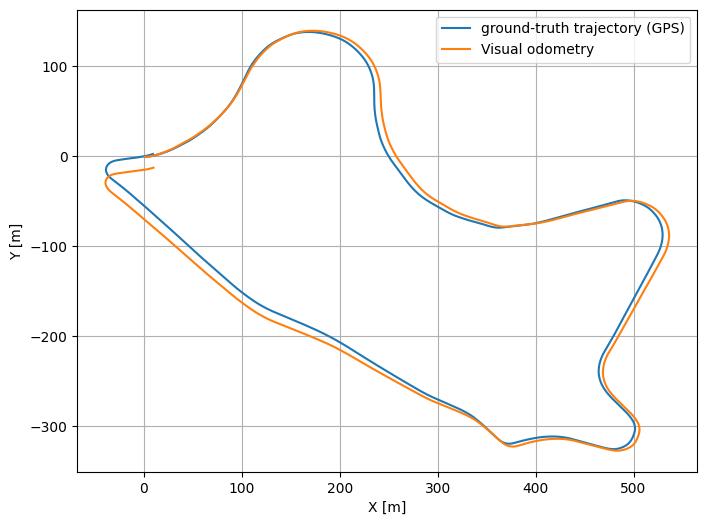

In [9]:
data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0)

In [4]:
x_setup1, P_setup1, H_setup1 = data.get_initial_data(setup=SetupEnum.SETUP_1)
x_setup2, P_setup2, H_setup2 = data.get_initial_data(setup=SetupEnum.SETUP_2)
x_setup3, P_setup3, H_setup3 = data.get_initial_data(setup=SetupEnum.SETUP_3)

alpha_setup1 = 1.0
beta_setup1 = 2.0
kappa_setup1 = 0.0

alpha_setup2 = 0.6
beta_setup2 = 2.0
kappa_setup2 = 0.0

alpha_setup3 = 0.0001
beta_setup3 = 2.0
kappa_setup3 = 0.0

n_samples = 2048
resampling_algorithm = ResamplingAlgorithms.STRATIFIED

n_ensemble = 2048

In [10]:
def visualize_result(mae_error_df, rmse_error_df, max_error_df):
    fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(8, 8))
    sns.heatmap(mae_error_df,
                ax=ax1,
                cmap="crest",
                annot=True,
                linewidths=1,
                fmt='.3g')
    ax1.set_title("Mean Absolute Error")
    ax1.set(xlabel="Downsampling ratio", ylabel="Filter type")
    
    sns.heatmap(rmse_error_df,
                ax=ax2,
                cmap="crest",
                annot=True,
                linewidths=1,
                fmt='.3g')
    ax2.set_title("Root Mean Squared Error")
    ax2.set(xlabel="Downsampling ratio", ylabel="Filter type")
    
    sns.heatmap(max_error_df,
                ax=ax3,
                cmap="crest",
                annot=True,
                linewidths=1,
                fmt='.3g')
    ax3.set_title("Maximum Error")
    ax3.set(xlabel="Downsampling ratio", ylabel="Filter type")
    
    fig.tight_layout()

def get_error_dataframe(ekf_result, ukf_result, pf_result, enkf_result, ckf_result):
    ekf_mae_error = get_error_from_list(ekf_result, e_type=ErrorEnum.MAE)
    ukf_mae_error = get_error_from_list(ukf_result, e_type=ErrorEnum.MAE)
    pf_mae_error = get_error_from_list(pf_result, e_type=ErrorEnum.MAE)
    enkf_mae_error = get_error_from_list(enkf_result, e_type=ErrorEnum.MAE)
    ckf_mae_error = get_error_from_list(ckf_result, e_type=ErrorEnum.MAE)
    
    ekf_rmse_error = get_error_from_list(ekf_result, e_type=ErrorEnum.RMSE)
    ukf_rmse_error = get_error_from_list(ukf_result, e_type=ErrorEnum.RMSE)
    pf_rmse_error = get_error_from_list(pf_result, e_type=ErrorEnum.RMSE)
    enkf_rmse_error = get_error_from_list(enkf_result, e_type=ErrorEnum.RMSE)
    ckf_rmse_error = get_error_from_list(ckf_result, e_type=ErrorEnum.RMSE)
    
    ekf_max_error = get_error_from_list(ekf_result, e_type=ErrorEnum.MAX)
    ukf_max_error = get_error_from_list(ukf_result, e_type=ErrorEnum.MAX)
    pf_max_error = get_error_from_list(pf_result, e_type=ErrorEnum.MAX)
    enkf_max_error = get_error_from_list(enkf_result, e_type=ErrorEnum.MAX)
    ckf_max_error = get_error_from_list(ckf_result, e_type=ErrorEnum.MAX)
    
    mae_error = [ekf_mae_error, ukf_mae_error, pf_mae_error, enkf_mae_error, ckf_mae_error]
    rmse_error = [ekf_rmse_error, ukf_rmse_error, pf_rmse_error, enkf_rmse_error, ckf_rmse_error]
    max_error = [ekf_max_error, ukf_max_error, pf_max_error, enkf_max_error, ckf_max_error]
        
    result = [ekf_mae_error, ukf_mae_error, pf_mae_error, enkf_mae_error, ckf_mae_error, \
             ekf_rmse_error, ukf_rmse_error, pf_rmse_error, enkf_rmse_error, ckf_rmse_error, \
             ekf_max_error, ukf_max_error, pf_max_error, enkf_max_error, ckf_max_error]
    
    mae_error_df = pd.DataFrame(np.array(mae_error),
                                 columns=downsampling_ratio_str, 
                                 index=filter_str)
    rmse_error_df = pd.DataFrame(np.array(rmse_error),
                                 columns=downsampling_ratio_str, 
                                 index=filter_str)
    max_error_df = pd.DataFrame(np.array(max_error),
                                 columns=downsampling_ratio_str, 
                                 index=filter_str)
    result_df = pd.DataFrame(np.array(result).T, 
                            index=[str(i) for i in downsampling_ratios], 
                            columns=setup_header)
    return result_df, mae_error_df, rmse_error_df, max_error_df

# Setup1 (IMU, VO)

In [6]:
ekf_results_setup1 = []
ukf_results_setup1 = []
pf_results_setup1 = []
enkf_results_setup1 = []
ckf_results_setup1 = []

In [7]:
for downsampling_rate in tqdm(downsampling_rate_list):
    data.set_downsampling_ratio(ratio=downsampling_rate)
    data.set_data_sampling(sampling=SamplingEnum.DOWNSAMPLED_DATA)

    ekf1 = ExtendedKalmanFilter(x=x_setup1.copy(), 
                                P=P_setup1.copy(), 
                                H=H_setup1.copy())
    
    ukf1 = UnscentedKalmanFilter(x=x_setup1.copy(), 
                                 P=P_setup1.copy(), 
                                 H=H_setup1.copy(), 
                                 alpha=alpha_setup1, 
                                 beta=beta_setup1, 
                                 kappa=kappa_setup1)
    
    pf1 = ParticleFilter(N=n_samples, 
                           x_dim=x_setup1.shape[0], 
                           H=H_setup1.copy(), 
                           resampling_algorithm=resampling_algorithm)
    pf1.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())
    
    enkf1 = EnsembleKalmanFilter(N=n_ensemble, 
                                   x=x_setup1.copy(), 
                                   P=P_setup1.copy(), 
                                   H=H_setup1.copy())
    
    ckf1_0 = CubatureKalmanFilter(x=x_setup1.copy(), 
                                  P=P_setup1.copy(), 
                                  H=H_setup1.copy())

    error_ekf1 = ekf1.run(data=data, 
                          setup=SetupEnum.SETUP_1,
                          debug_mode=False)
    error_ukf1 = ukf1.run(data=data, 
                          setup=SetupEnum.SETUP_1,
                          debug_mode=False)
    error_pf1 = pf1.run(data=data, 
                        setup=SetupEnum.SETUP_1,
                        debug_mode=False)
    error_enkf1 = enkf1.run(data=data, 
                            setup=SetupEnum.SETUP_1,
                            debug_mode=False)
    error_ckf1_0 = ckf1_0.run(
        data=data,
        setup=SetupEnum.SETUP_1,
        debug_mode=False,
    )

    ekf_results_setup1.append(error_ekf1)
    ukf_results_setup1.append(error_ukf1)
    pf_results_setup1.append(error_pf1)
    enkf_results_setup1.append(error_enkf1)
    ckf_results_setup1.append(error_ckf1_0)
    

  0%|                                                                                                               | 0/10 [00:00<?, ?it/s]

Data is sampled and synchronized at original sampling frequency (10Hz).
Shapes after downsampling
time: (1591,)
GPS: (1591, 3)
INS: (1591, 3)
IMU (angular vel): (1591, 3)
IMU (linear acc): (1591, 3)
Data sampling is set to downsampling mode.


 10%|██████████▎                                                                                            | 1/10 [01:16<11:24, 76.06s/it]

Data is sampled and synchronized at 9Hz.
Shapes after downsampling
time: (1431,)
GPS: (1431, 3)
INS: (1431, 3)
IMU (angular vel): (1431, 3)
IMU (linear acc): (1431, 3)
Data sampling is set to downsampling mode.


 20%|████████████████████▌                                                                                  | 2/10 [02:23<09:29, 71.25s/it]

...

 80%|██████████████████████████████████████████████████████████████████████████████████▍                    | 8/10 [06:32<01:13, 36.52s/it]

Data is sampled and synchronized at 2Hz.
Shapes after downsampling
time: (318,)
GPS: (318, 3)
INS: (318, 3)
IMU (angular vel): (318, 3)
IMU (linear acc): (318, 3)
Data sampling is set to downsampling mode.


 90%|████████████████████████████████████████████████████████████████████████████████████████████▋          | 9/10 [06:47<00:29, 29.79s/it]

Data is sampled and synchronized at 1Hz.
Shapes after downsampling
time: (159,)
GPS: (159, 3)
INS: (159, 3)
IMU (angular vel): (159, 3)
IMU (linear acc): (159, 3)
Data sampling is set to downsampling mode.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:54<00:00, 41.46s/it]


In [12]:
result_setup1, mae_error_df_1, rmse_error_df_1, max_error_df_1 = get_error_dataframe(
    ekf_result=ekf_results_setup1,
    ukf_result=ukf_results_setup1,
    pf_result=pf_results_setup1,
    enkf_result=enkf_results_setup1,
    ckf_result=ckf_results_setup1
)
result_setup1

Error types    MAE                                      RMSE          \
Filters        EKF     UKF          PF   EnKF     CKF    EKF     UKF   
0.0          4.015   3.870       3.896  4.176   3.909  5.699   5.399   
0.1          4.001   4.001       3.897  4.159   3.997  5.692   5.546   
0.2          4.008   4.020       3.901  4.168   4.075  5.696   5.529   
0.3          4.007   4.231       3.892  4.192   4.145  5.683   5.671   
0.4          4.031   4.419       3.897  4.254   4.200  5.724   5.874   
0.5          4.074   4.717       3.929  4.315   4.573  5.768   6.121   
0.6          4.105   5.332       3.910  4.254   4.950  5.791   6.960   
0.7          4.179   6.763       3.921  4.542   5.590  5.829   9.225   
0.8          4.153  12.515       3.904  4.863  10.078  5.542  19.937   
0.9          4.719  45.584  111570.089  5.232  35.200  6.037  65.956   

Error types                                MAX                               \
Filters              PF   EnKF     CKF     EKF      UKF          PF    EnKF   
0.0               5.496  5.704   5.489  18.331   16.053      16.402  18.587   
0.1               5.510  5.686   5.560  18.570   16.243      16.493  18.679   
0.2               5.510  5.719   5.537  18.677   16.231      16.432  18.325   
0.3               5.489  5.684   5.629  18.654   17.205      16.222  21.126   
0.4               5.515  5.753   5.700  18.347   18.796      16.620  18.375   
0.5               5.525  5.811   5.982  18.696   18.574      16.493  19.447   
0.6               5.514  5.664   6.265  18.637   19.711      15.867  19.058   
0.7               5.529  5.995   7.089  19.371   33.541      16.646  21.124   
0.8               5.504  6.182  14.866  17.054   72.007      15.881  19.242   
0.9          181067.760  6.603  50.670  18.416  193.542  482876.239  22.078   

Error types           
Filters          CKF  
0.0           16.347  
0.1           17.138  
0.2           17.264  
0.3           17.191  
0.4           16.273  
0.5           19.402  
0.6           20.692  
0.7           21.286  
0.8           57.364  
0.9          165.617

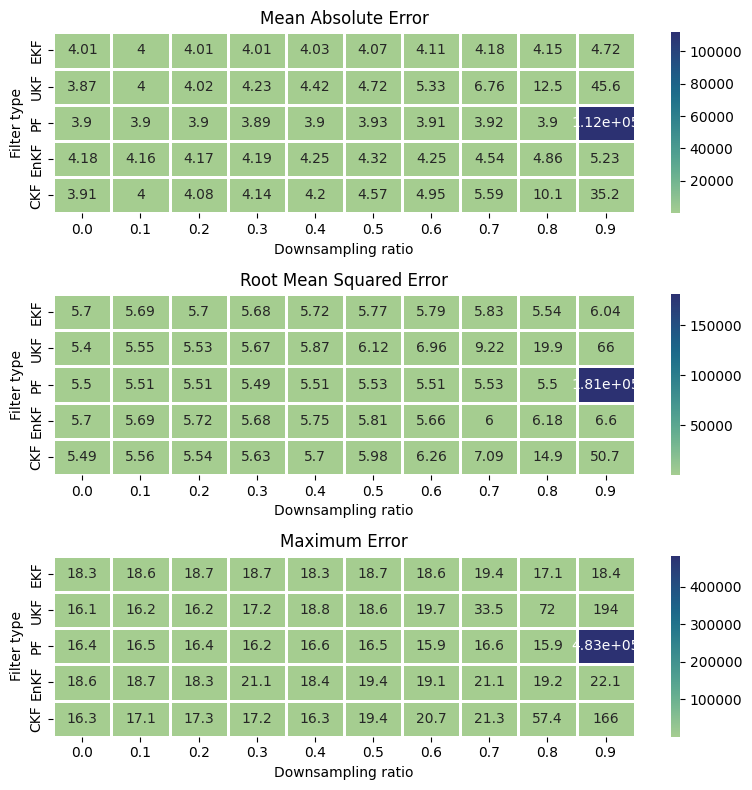

In [13]:
visualize_result(mae_error_df=mae_error_df_1, 
                 rmse_error_df=rmse_error_df_1, 
                 max_error_df=max_error_df_1)

# Setup2 (IMU, VO+GPS)

In [14]:
ekf_results_setup2 = []
ukf_results_setup2 = []
pf_results_setup2 = []
enkf_results_setup2 = []
ckf_results_setup2 = []

In [15]:
for downsampling_rate in tqdm(downsampling_rate_list):
    data.set_downsampling_ratio(ratio=downsampling_rate)
    data.set_data_sampling(sampling=SamplingEnum.DOWNSAMPLED_DATA)

    ekf2 = ExtendedKalmanFilter(x=x_setup2.copy(), 
                                P=P_setup2.copy(), 
                                H=H_setup2.copy())
    
    ukf2 = UnscentedKalmanFilter(x=x_setup2.copy(), 
                                 P=P_setup2.copy(), 
                                 H=H_setup2.copy(), 
                                 alpha=alpha_setup2, 
                                 beta=beta_setup2, 
                                 kappa=kappa_setup2)
    
    pf2 = ParticleFilter(N=n_samples, 
                           x_dim=x_setup2.shape[0], 
                           H=H_setup2.copy(), 
                           resampling_algorithm=resampling_algorithm)
    pf2.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())
    
    enkf2 = EnsembleKalmanFilter(N=n_ensemble, 
                                   x=x_setup2.copy(), 
                                   P=P_setup2.copy(), 
                                   H=H_setup2.copy())
    
    ckf2_0 = CubatureKalmanFilter(x=x_setup2.copy(), 
                                  P=P_setup2.copy(), 
                                  H=H_setup2.copy())

    error_ekf2 = ekf2.run(data=data, 
                          setup=SetupEnum.SETUP_2,
                          debug_mode=False)
    error_ukf2 = ukf2.run(data=data, 
                          setup=SetupEnum.SETUP_2,
                          debug_mode=False)
    error_pf2 = pf2.run(data=data, 
                        setup=SetupEnum.SETUP_2,
                        debug_mode=False)
    error_enkf2 = enkf2.run(data=data, 
                            setup=SetupEnum.SETUP_2,
                            debug_mode=False)
    error_ckf2_0 = ckf2_0.run(
        data=data, 
        setup=SetupEnum.SETUP_2, 
        debug_mode=False
    )
    
    ekf_results_setup2.append(error_ekf2)
    ukf_results_setup2.append(error_ukf2)
    pf_results_setup2.append(error_pf2)
    enkf_results_setup2.append(error_enkf2)
    ckf_results_setup2.append(error_ckf2_0)
    

  0%|                                                                                                               | 0/10 [00:00<?, ?it/s]

Data is sampled and synchronized at original sampling frequency (10Hz).
Shapes after downsampling
time: (1591,)
GPS: (1591, 3)
INS: (1591, 3)
IMU (angular vel): (1591, 3)
IMU (linear acc): (1591, 3)
Data sampling is set to downsampling mode.


 10%|██████████▏                                                                                           | 1/10 [02:07<19:04, 127.20s/it]

Data is sampled and synchronized at 9Hz.
Shapes after downsampling
time: (1431,)
GPS: (1431, 3)
INS: (1431, 3)
IMU (angular vel): (1431, 3)
IMU (linear acc): (1431, 3)
Data sampling is set to downsampling mode.


 20%|████████████████████▍                                                                                 | 2/10 [04:01<15:57, 119.64s/it]

...

 80%|██████████████████████████████████████████████████████████████████████████████████▍                    | 8/10 [11:07<02:04, 62.42s/it]

Data is sampled and synchronized at 2Hz.
Shapes after downsampling
time: (318,)
GPS: (318, 3)
INS: (318, 3)
IMU (angular vel): (318, 3)
IMU (linear acc): (318, 3)
Data sampling is set to downsampling mode.


 90%|████████████████████████████████████████████████████████████████████████████████████████████▋          | 9/10 [11:33<00:50, 50.87s/it]

Data is sampled and synchronized at 1Hz.
Shapes after downsampling
time: (159,)
GPS: (159, 3)
INS: (159, 3)
IMU (angular vel): (159, 3)
IMU (linear acc): (159, 3)
Data sampling is set to downsampling mode.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [11:45<00:00, 70.58s/it]


In [16]:
result_setup2, mae_error_df_2, rmse_error_df_2, max_error_df_2 = get_error_dataframe(
    ekf_result=ekf_results_setup2,
    ukf_result=ukf_results_setup2,
    pf_result=pf_results_setup2,
    enkf_result=enkf_results_setup2,
    ckf_result=ckf_results_setup2,
)
result_setup2

Error types    MAE                                   RMSE                     \
Filters        EKF    UKF         PF   EnKF    CKF    EKF     UKF         PF   
0.0          2.137  1.551      0.553  1.222  1.536  2.977   2.127      0.699   
0.1          2.137  1.535      0.566  1.272  1.561  2.971   2.075      0.716   
0.2          2.151  1.545      0.575  1.271  1.557  2.980   2.080      0.724   
0.3          2.148  1.541      0.583  1.405  1.557  2.983   2.037      0.735   
0.4          2.163  1.571      0.592  1.467  1.596  3.008   2.073      0.745   
0.5          2.124  1.587      0.615  1.588  1.605  2.790   2.079      0.777   
0.6          2.145  1.665      0.631  1.727  1.663  2.817   2.148      0.798   
0.7          2.310  1.843      0.671  1.889  1.941  3.102   2.349      0.835   
0.8          2.290  3.019      0.683  2.208  3.258  2.945   3.890      0.869   
0.9          2.892  8.050  25239.668  4.390  7.818  3.610  12.485  42389.560   

Error types                    MAX                                      
Filters       EnKF     CKF     EKF     UKF          PF    EnKF     CKF  
0.0          1.565   2.074  10.313   7.032       3.024   9.259   6.567  
0.1          1.622   2.105  10.372   6.499       3.413   7.220   6.648  
0.2          1.648   2.091  10.352   6.662       2.911   7.942   6.558  
0.3          1.799   2.062  10.726   6.877       3.445   7.068   6.324  
0.4          1.878   2.081  10.514   6.617       2.723   8.090   6.409  
0.5          2.020   2.109   8.448   6.960       3.129  10.035   6.881  
0.6          2.223   2.158   8.300   6.450       3.600   8.697   6.424  
0.7          2.379   2.511  10.715   6.801       2.504   7.913   9.174  
0.8          2.831   4.636   8.700  15.939       3.326  11.387  16.339  
0.9          6.095  12.759  10.698  45.929  140600.537  38.947  46.702

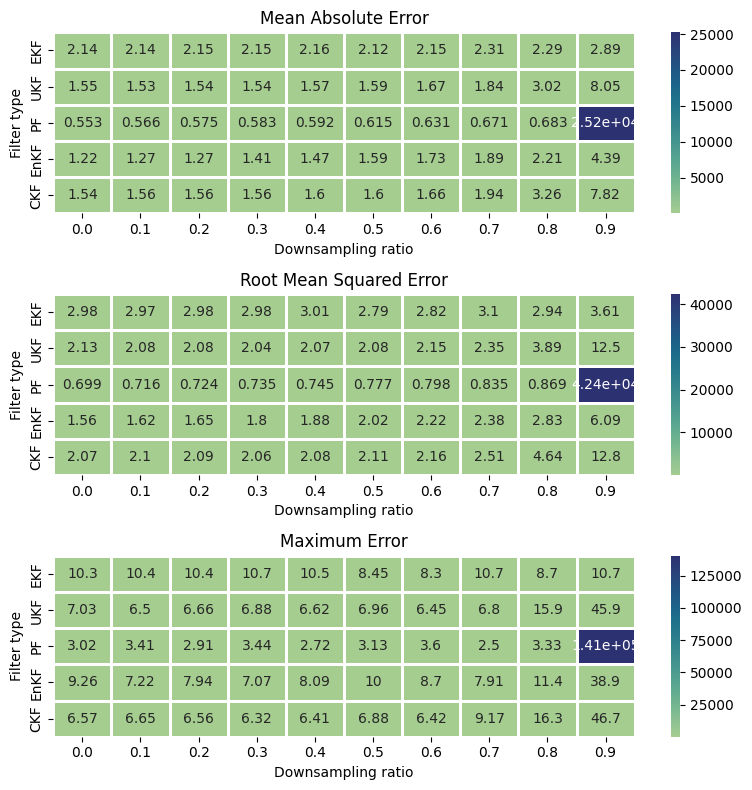

In [17]:
visualize_result(mae_error_df=mae_error_df_2, 
                 rmse_error_df=rmse_error_df_2, 
                 max_error_df=max_error_df_2)

# Setup3 (INS)

In [18]:
ekf_results_setup3 = []
ukf_results_setup3 = []
pf_results_setup3 = []
enkf_results_setup3 = []
ckf_results_setup3 = []

In [20]:
for downsampling_rate in tqdm(downsampling_rate_list):
    data.set_downsampling_ratio(ratio=downsampling_rate)
    data.set_data_sampling(sampling=SamplingEnum.DOWNSAMPLED_DATA)

    ekf3 = ExtendedKalmanFilter(x=x_setup3.copy(), 
                                P=P_setup3.copy(), 
                                H=H_setup3.copy())
    
    ukf3 = UnscentedKalmanFilter(x=x_setup3.copy(), 
                                 P=P_setup3.copy(), 
                                 H=H_setup3.copy(), 
                                 alpha=alpha_setup3, 
                                 beta=beta_setup3, 
                                 kappa=kappa_setup3)
    
    pf3 = ParticleFilter(N=n_samples, 
                           x_dim=x_setup3.shape[0], 
                           H=H_setup3.copy(), 
                           resampling_algorithm=resampling_algorithm)
    pf3.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())
    
    enkf3 = EnsembleKalmanFilter(N=n_ensemble, 
                                   x=x_setup3.copy(), 
                                   P=P_setup3.copy(), 
                                   H=H_setup3.copy())
    
    ckf3_0 = CubatureKalmanFilter(x=x_setup3.copy(), 
                              P=P_setup3.copy(), 
                              H=H_setup3.copy())
    
    error_ekf3 = ekf3.run(data=data, 
                          setup=SetupEnum.SETUP_3,
                          debug_mode=False)
    error_ukf3 = ukf3.run(data=data, 
                          setup=SetupEnum.SETUP_3,
                          debug_mode=False)
    error_pf3 = pf3.run(data=data, 
                        setup=SetupEnum.SETUP_3,
                        debug_mode=False)
    error_enkf3 = enkf3.run(data=data, 
                            setup=SetupEnum.SETUP_3,
                            debug_mode=False)
    error_ckf3_0 = ckf3_0.run(
        data=data, 
        setup=SetupEnum.SETUP_3,
        debug_mode=False
    )
    
    ekf_results_setup3.append(error_ekf3)
    ukf_results_setup3.append(error_ukf3)
    pf_results_setup3.append(error_pf3)
    enkf_results_setup3.append(error_enkf3)
    ckf_results_setup3.append(error_ckf3_0)
    

  0%|                                                                                                               | 0/10 [00:00<?, ?it/s]

Data is sampled and synchronized at original sampling frequency (10Hz).
Shapes after downsampling
time: (1591,)
GPS: (1591, 3)
INS: (1591, 3)
IMU (angular vel): (1591, 3)
IMU (linear acc): (1591, 3)
Data sampling is set to downsampling mode.


 10%|██████████▏                                                                                           | 1/10 [01:43<15:29, 103.29s/it]

Data is sampled and synchronized at 9Hz.
Shapes after downsampling
time: (1431,)
GPS: (1431, 3)
INS: (1431, 3)
IMU (angular vel): (1431, 3)
IMU (linear acc): (1431, 3)
Data sampling is set to downsampling mode.


 20%|████████████████████▌                                                                                  | 2/10 [03:15<12:54, 96.81s/it]

...

 80%|██████████████████████████████████████████████████████████████████████████████████▍                    | 8/10 [08:54<01:39, 49.79s/it]

Data is sampled and synchronized at 2Hz.
Shapes after downsampling
time: (318,)
GPS: (318, 3)
INS: (318, 3)
IMU (angular vel): (318, 3)
IMU (linear acc): (318, 3)
Data sampling is set to downsampling mode.


 90%|████████████████████████████████████████████████████████████████████████████████████████████▋          | 9/10 [09:14<00:40, 40.66s/it]

Data is sampled and synchronized at 1Hz.
Shapes after downsampling
time: (159,)
GPS: (159, 3)
INS: (159, 3)
IMU (angular vel): (159, 3)
IMU (linear acc): (159, 3)
Data sampling is set to downsampling mode.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [09:25<00:00, 56.52s/it]


In [21]:
result_setup3, mae_error_df_3, rmse_error_df_3, max_error_df_3 = get_error_dataframe(ekf_result=ekf_results_setup3,
                                                                                     ukf_result=ukf_results_setup3,
                                                                                     pf_result=pf_results_setup3,
                                                                                     enkf_result=enkf_results_setup3,
                                                                                     ckf_result=ckf_results_setup3
                                                                                    )
result_setup3

Error types    MAE                               RMSE                       \
Filters        EKF    UKF     PF   EnKF    CKF    EKF    UKF     PF   EnKF   
0.0          1.915  1.818  0.291  0.815  1.819  2.739  2.566  0.365  1.023   
0.1          1.914  1.814  0.297  0.824  1.815  2.740  2.562  0.373  1.036   
0.2          1.922  1.819  0.307  0.812  1.819  2.748  2.565  0.385  1.024   
0.3          1.931  1.818  0.309  0.815  1.818  2.743  2.555  0.383  1.027   
0.4          1.918  1.809  0.305  0.829  1.810  2.744  2.553  0.381  1.036   
0.5          1.946  1.824  0.302  0.840  1.825  2.749  2.546  0.386  1.058   
0.6          1.957  1.820  0.320  0.853  1.820  2.769  2.554  0.395  1.077   
0.7          1.954  1.803  0.346  0.871  1.803  2.764  2.531  0.442  1.086   
0.8          1.969  1.780  0.434  0.866  1.777  2.774  2.505  0.547  1.094   
0.9          2.092  1.894  0.861  0.996  1.898  2.814  2.481  1.063  1.247   

Error types           MAX                              
Filters        CKF    EKF    UKF     PF   EnKF    CKF  
0.0          2.566  8.089  7.591  1.325  4.355  7.591  
0.1          2.562  8.026  7.613  1.426  4.374  7.610  
0.2          2.565  8.127  7.614  1.352  4.542  7.615  
0.3          2.555  8.152  7.632  1.445  4.356  7.634  
0.4          2.553  8.070  7.608  1.332  4.337  7.614  
0.5          2.547  8.164  7.615  1.496  4.386  7.621  
0.6          2.554  8.116  7.442  1.426  4.347  7.442  
0.7          2.532  8.067  7.414  1.652  3.503  7.412  
0.8          2.502  8.515  7.569  1.843  4.247  7.555  
0.9          2.485  8.829  7.124  2.908  3.794  7.141

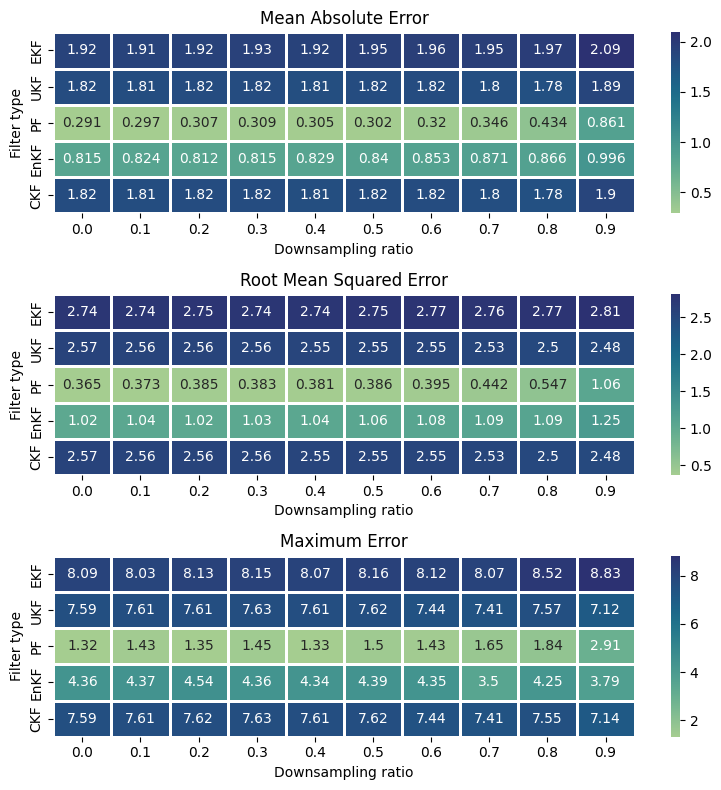

In [22]:
visualize_result(mae_error_df=mae_error_df_3, 
                 rmse_error_df=rmse_error_df_3, 
                 max_error_df=max_error_df_3)

# Results

### Setup1

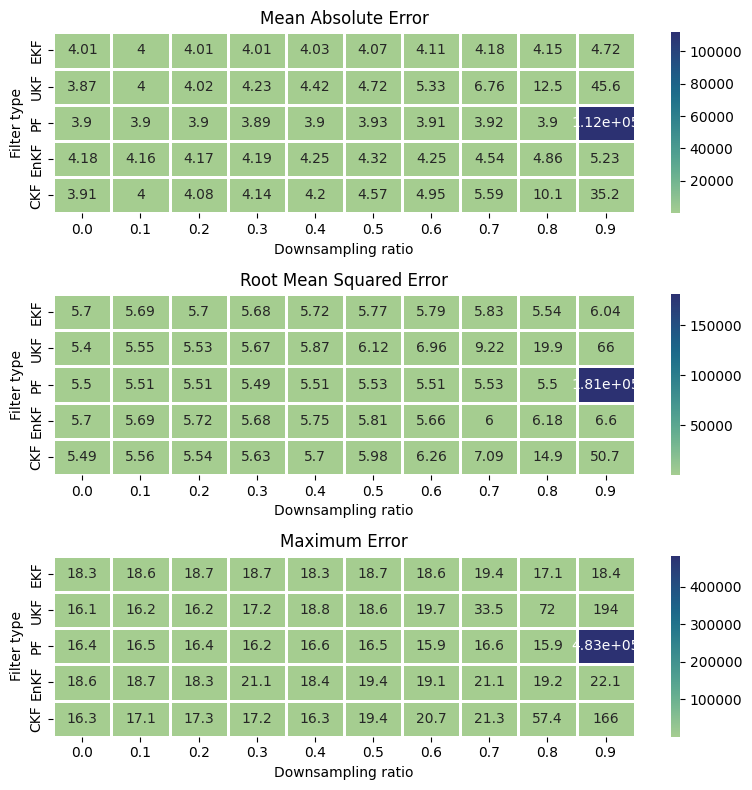

In [23]:
visualize_result(mae_error_df=mae_error_df_1, 
                 rmse_error_df=rmse_error_df_1, 
                 max_error_df=max_error_df_1)

### Setup2

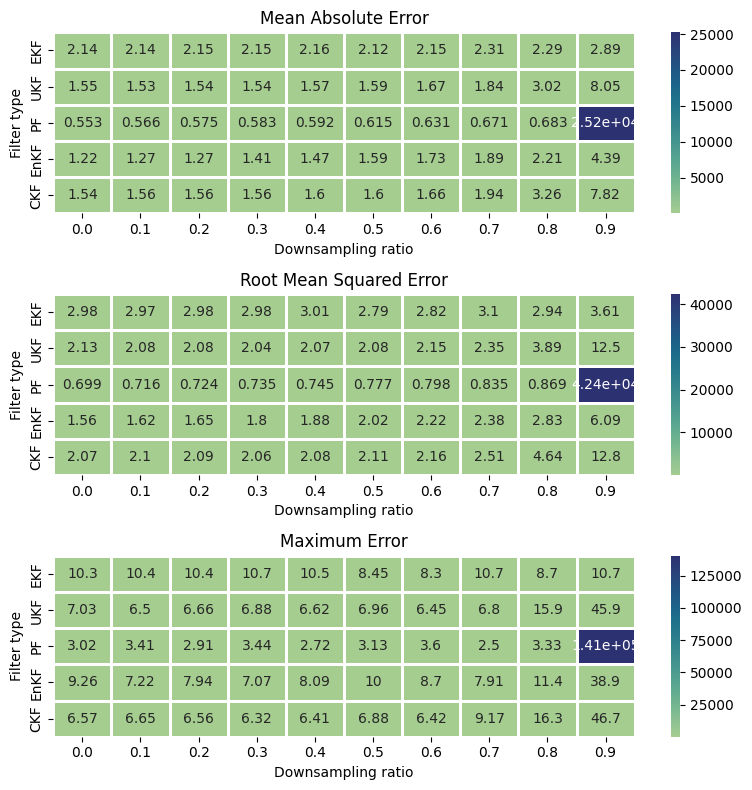

In [24]:
visualize_result(mae_error_df=mae_error_df_2, 
                 rmse_error_df=rmse_error_df_2, 
                 max_error_df=max_error_df_2)

### Setup3

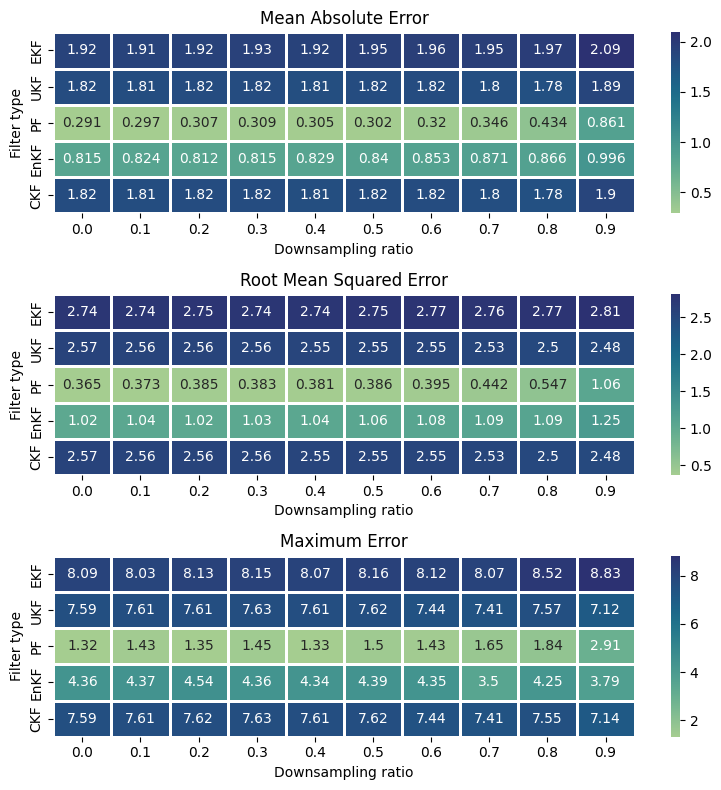

In [25]:
visualize_result(mae_error_df=mae_error_df_3, 
                 rmse_error_df=rmse_error_df_3, 
                 max_error_df=max_error_df_3)

# Conclusion

In this notebook, for all implemented filters, the impact of feeding downsampled measurement VO and GPS data, on the filter estimation is tested.
